# Chuvas e Deslizamentos no Estado do Rio de Janeiro (2015–2024)
### Avaliação G1 — Projeto de Análise e Visualização de Dados com Python · Notebook de análise

| | |
|---|---|
| **Disciplina** | Linguagem de Programação — Análise e Visualização de Dados com Python |
| **Mês/Ano** | Outubro de 2026 |
| **Professor** | Alexandre Louzada |
| **Aluno** | Lucas Queiroz Paes Leme |
| **Tema** | 2 — Chuvas e Deslizamentos no Estado do Rio de Janeiro |
| **Base** | `simulacao_chuvas_deslizamentos_rj.csv` (dados simulados) |

> Este notebook é a etapa de **análise exploratória** do projeto. O resultado final está no dashboard Streamlit (`app.py`) e na página do projeto (`index.html`).

## 1. Introdução ao problema

Chuvas intensas provocam **enchentes, alagamentos e deslizamentos de terra**, principalmente onde há relevo acidentado, ocupação irregular de encostas e infraestrutura inadequada. O Estado do Rio de Janeiro tem um histórico recorrente de desastres desse tipo, sobretudo nas cidades serranas, com pessoas desalojadas e óbitos.

**Pergunta central do projeto:**
> *Qual é a relação entre o volume de chuva e os deslizamentos nos municípios do Rio de Janeiro, quais municípios e períodos são os mais críticos e onde e quando agir para reduzir o risco?*

**Perguntas orientadoras**
1. Quais municípios apresentam maior volume de chuva?
2. Quais municípios registram mais deslizamentos?
3. Existem meses mais críticos?
4. Há relação entre chuva intensa e aumento de deslizamentos?
5. Quais cidades apresentam maior risco?
6. Existem períodos sazonais de maior vulnerabilidade?
7. Há municípios com comportamento fora do padrão?

## 2. Contextualização do problema

- Um deslizamento ocorre quando a encosta perde estabilidade. A **chuva intensa ou prolongada** encharca o solo (aumenta a **saturação**), eleva o peso da massa de terra e reduz o atrito, e a encosta cede.
- **Relevo e ocupação** importam: cidades serranas (Petrópolis, Teresópolis e Nova Friburgo) têm vales e encostas íngremes, e onde há moradias em áreas de risco o mesmo volume de chuva gera mais ocorrências e mais vítimas.
- No Sudeste, o **verão (dezembro a março) é a estação chuvosa**, com chuvas fortes de origem convectiva e frentes frias.
- Medidas típicas: mapeamento de áreas de risco, obras de contenção, drenagem, sirenes e planos de evacuação acionados por **alertas de chuva**.

**O que se espera de uma base realista:** forte sazonalidade (verão), relação positiva entre chuva e deslizamentos, municípios serranos mais vulneráveis e ocorrências maiores quando o solo já está saturado. **Vamos testar se a base mostra isso.**

## 3. Explicação da base de dados

Arquivo: `simulacao_chuvas_deslizamentos_rj.csv` — **960 linhas × 14 colunas**: 8 municípios × 120 meses (janeiro/2015 a dezembro/2024), distribuídos em 5 regiões do estado. São **dados simulados** (fictícios), fornecidos pelo professor.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período da ocorrência (a `data` é o 1º dia do mês) |
| `municipio`, `regiao_rj` | Município e região do estado |
| `populacao` | População estimada |
| `chuva_mm` | Volume de chuva no mês (mm) |
| `temperatura_media` | Temperatura média (°C) |
| `ocorrencias_deslizamento` | Número de deslizamentos no mês |
| `desalojados`, `obitos` | Pessoas desalojadas e óbitos registrados |
| `nivel_risco` | Classificação: Baixo, Médio, Alto ou Crítico |
| `indice_solo` | Índice de saturação do solo (0 a 1) |
| `umidade` | Umidade relativa do ar (%) |

**Municípios:** Rio de Janeiro e Niterói (Metropolitana), Nova Iguaçu (Baixada), Petrópolis, Teresópolis e Nova Friburgo (Serrana), Angra dos Reis (Costa Verde) e Campos dos Goytacazes (Norte Fluminense).

## 4. Leitura dos dados

In [1]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 10})
pd.options.display.float_format = "{:,.2f}".format

# Pasta onde os gráficos serão salvos (usados no README e na página do projeto)
PASTA_IMG = "../imagens" if os.path.isdir("../dados") else "imagens"
os.makedirs(PASTA_IMG, exist_ok=True)

In [2]:
ARQUIVO = "simulacao_chuvas_deslizamentos_rj.csv"
URL = ("https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados-G2/main/"
       "datasets_g2_30_temas/" + ARQUIVO)

# Ordem de tentativas: 1) pasta do projeto  2) GitHub (requests)  3) upload manual no Colab
if os.path.exists("../dados/" + ARQUIVO):
    df_raw = pd.read_csv("../dados/" + ARQUIVO, encoding="utf-8-sig")
    print("Dados lidos da pasta do projeto (../dados).")
else:
    try:
        import requests
        resposta = requests.get(URL, timeout=30)
        resposta.raise_for_status()
        df_raw = pd.read_csv(io.StringIO(resposta.content.decode("utf-8-sig")))
        print("Dados baixados do GitHub com requests.")
    except Exception as erro:
        print(f"Falha no download ({erro}). Faça o upload do CSV:")
        from google.colab import files
        enviado = files.upload()
        df_raw = pd.read_csv(list(enviado.keys())[0], encoding="utf-8-sig")
        print("Dados lidos do upload.")

print(f"Formato da base: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
df_raw.head(10)

Dados lidos da pasta do projeto (../dados).
Formato da base: 960 linhas x 14 colunas


,ano,mes,data,municipio,regiao_rj,populacao,chuva_mm,temperatura_media,ocorrencias_deslizamento,desalojados,obitos,nivel_risco,indice_solo,umidade
0,2015,1,2015-01-01,Rio de Janeiro,Metropolitana,4091571,189.10,24.80,6,64,0,Crítico,0.72,88.20
1,2015,1,2015-01-01,Niterói,Metropolitana,5475024,316.20,24.30,5,58,1,Alto,1.00,93.50
2,2015,1,2015-01-01,Nova Iguaçu,Baixada,2104552,205.30,25.50,10,108,0,Crítico,0.87,82.20
3,2015,1,2015-01-01,Petrópolis,Serrana,4207259,108.80,28.10,3,24,0,Alto,0.50,60.90
4,2015,1,2015-01-01,Teresópolis,Serrana,4424517,204.20,26.80,9,85,0,Crítico,0.68,65.00
5,2015,1,2015-01-01,Nova Friburgo,Serrana,1618558,298.70,27.40,15,139,2,Crítico,1.00,72.30
6,2015,1,2015-01-01,Angra dos Reis,Costa Verde,2724271,221.40,23.00,5,45,0,Alto,0.88,86.40
7,2015,1,2015-01-01,Campos dos Goytacazes,Norte Fluminense,4200629,177.10,23.60,4,40,0,Alto,0.76,78.70
8,2015,2,2015-02-01,Rio de Janeiro,Metropolitana,5542642,220.90,24.10,6,66,1,Crítico,0.86,74.90
9,2015,2,2015-02-01,Niterói,Metropolitana,3323539,184.40,23.90,1,10,0,Médio,0.64,90.50


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ano                       960 non-null    int64  
 1   mes                       960 non-null    int64  
 2   data                      960 non-null    str    
 3   municipio                 960 non-null    str    
 4   regiao_rj                 960 non-null    str    
 5   populacao                 960 non-null    int64  
 6   chuva_mm                  960 non-null    float64
 7   temperatura_media         960 non-null    float64
 8   ocorrencias_deslizamento  960 non-null    int64  
 9   desalojados               960 non-null    int64  
 10  obitos                    960 non-null    int64  
 11  nivel_risco               960 non-null    str    
 12  indice_solo               960 non-null    float64
 13  umidade                   960 non-null    float64
dtypes: float64(4), int64(

## 5. Limpeza e preparação dos dados

Etapas: padronizar textos, converter tipos, tratar nulos e duplicados, validar faixas (chuva ≥ 0, índice do solo entre 0 e 1, umidade entre 0 e 100), procurar outliers e investigar a consistência das colunas (população, nível de risco, desalojados). Os nomes das colunas já estão padronizados (minúsculas, sem acento), então **não foi necessário renomear**.

In [4]:
df = df_raw.copy()

# 1) Padronização de textos
for col in ["municipio", "regiao_rj", "nivel_risco"]:
    df[col] = df[col].astype(str).str.strip()

# 2) Conversão de tipos
df["data"] = pd.to_datetime(df["data"], errors="coerce")
ORDEM_RISCO = ["Baixo", "Médio", "Alto", "Crítico"]
df["nivel_risco"] = pd.Categorical(df["nivel_risco"], categories=ORDEM_RISCO, ordered=True)

# 3) Valores nulos e duplicados
print("Valores nulos por coluna:\n", df.isna().sum().to_string(), "\n")
print("Linhas totalmente duplicadas:", df.duplicated().sum())
print("Chaves (data, município) repetidas:", df.duplicated(["data", "municipio"]).sum())
df = df.drop_duplicates()
df = df.dropna(subset=["data", "municipio", "chuva_mm", "ocorrencias_deslizamento"])   # (nada removido: não há nulos)

# 4) Validação das faixas de valores
print("\nchuva_mm < 0:", (df["chuva_mm"] < 0).sum())
print("ocorrencias_deslizamento < 0:", (df["ocorrencias_deslizamento"] < 0).sum())
print("indice_solo fora de [0, 1]:", (~df["indice_solo"].between(0, 1)).sum())
print("umidade fora de [0, 100]:", (~df["umidade"].between(0, 100)).sum())
print("Painel balanceado? registros por município:", df.groupby("municipio").size().unique())
print("Linhas após a limpeza:", len(df))

Valores nulos por coluna:
 ano                         0
mes                         0
data                        0
municipio                   0
regiao_rj                   0
populacao                   0
chuva_mm                    0
temperatura_media           0
ocorrencias_deslizamento    0
desalojados                 0
obitos                      0
nivel_risco                 0
indice_solo                 0
umidade                     0 

Linhas totalmente duplicadas: 0
Chaves (data, município) repetidas: 0

chuva_mm < 0: 0
ocorrencias_deslizamento < 0: 0
indice_solo fora de [0, 1]: 0
umidade fora de [0, 100]: 0
Painel balanceado? registros por município: [120]
Linhas após a limpeza: 960


In [5]:
# 5) Outliers pelo critério do IQR (1,5 x amplitude interquartil)
for col in ["chuva_mm", "ocorrencias_deslizamento", "desalojados", "obitos", "temperatura_media"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fora = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:26s} valores fora do IQR: {fora}")

chuva_mm                   valores fora do IQR: 8
ocorrencias_deslizamento   valores fora do IQR: 41
desalojados                valores fora do IQR: 47
obitos                     valores fora do IQR: 207
temperatura_media          valores fora do IQR: 2


**Outliers:** há 8 meses de chuva extrema e 41 registros com muitos deslizamentos. **Foram mantidos**: são eventos reais do fenômeno estudado (chuvas fortes e grandes deslizamentos), e não erros de medição. Remover esses casos eliminaria justamente o que a análise procura.

In [6]:
# 6) Consistência: a população muda de mês para mês no mesmo município?
df.groupby("municipio")["populacao"].agg(["min", "max", "nunique"]).astype(int)

,min,max,nunique
municipio,,,
Angra dos Reis,133533,6460674,120
Campos dos Goytacazes,120861,6483134,120
Niterói,233368,6423395,120
Nova Friburgo,135463,6467884,120
Nova Iguaçu,121646,6399875,120
Petrópolis,123511,6453762,120
Rio de Janeiro,239135,6485133,120
Teresópolis,131272,6427035,120


In [7]:
# 7) O nível de risco é função exata da chuva? (faixas de chuva por nível)
df.groupby("nivel_risco", observed=True)["chuva_mm"].agg(["min", "mean", "max", "count"])

,min,mean,max,count
nivel_risco,,,,
Baixo,0.00,40.06,129.50,117
Médio,0.00,83.36,213.20,222
Alto,27.30,128.67,316.20,245
Crítico,61.30,203.17,435.70,376


In [8]:
# 8) Desalojados x deslizamentos: razão e correlação
razao = df["desalojados"] / df["ocorrencias_deslizamento"].replace(0, np.nan)
print("Desalojados por deslizamento (mediana):", round(razao.median(), 1))
print("Correlação desalojados x deslizamentos:", round(df["desalojados"].corr(df["ocorrencias_deslizamento"]), 3))

Desalojados por deslizamento (mediana): 10.0
Correlação desalojados x deslizamentos: 0.991


**Decisões de limpeza e problemas encontrados**

- **Nulos, duplicatas e valores impossíveis:** não há (nada a remover).
- **Painel completo:** 8 municípios × 120 meses, sem lacunas.
- **`populacao` não é confiável:** cada município tem população **diferente em todos os meses**, entre ~120 mil e ~6,5 milhões (Niterói chega a ter mais habitantes que o Rio de Janeiro). Por isso **não calculei taxas por habitante** e usei apenas valores absolutos e relativos à chuva.
- **`nivel_risco` não é função exata da chuva:** as faixas se sobrepõem (por exemplo, há registros “Baixo” com mais de 100 mm). Ele será tratado como um indicador à parte, e comparado com a chuva e os deslizamentos.
- **`desalojados` é quase proporcional aos deslizamentos** (≈ 10 por ocorrência; r = 0,99): não traz informação independente e será usado como indicador de impacto.

## 6. Engenharia de atributos

| Variável | Como é calculada | Uso |
|---|---|---|
| `mes_nome` | Nome do mês | Rótulos |
| `estacao` | “Chuvosa (dez–mar)” se o mês é 12, 1, 2 ou 3; senão “Menos chuvosa (abr–nov)” | Sazonalidade |
| `critico` / `critico_pct` | 1 (ou 100) se `nivel_risco == "Crítico"` | % de registros críticos |
| `chuva_intensa` | 1 se `chuva_mm ≥ 200` | Alerta |
| `solo_saturado` | 1 se `indice_solo ≥ 0,8` | Alerta |
| `faixa_chuva` | Faixas de 0–50, 50–100, 100–150, 150–200, 200–300 e > 300 mm | Dose-resposta |
| `ocorrencias_esperadas` e `residuo` | Deslizamentos previstos pela reta ajustada com a chuva e diferença para o observado | Municípios fora do padrão |

In [9]:
NOMES_MESES = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
               7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"}
MESES_CHUVOSOS = [12, 1, 2, 3]
ROTULO_CHUVOSA, ROTULO_MENOS = "Chuvosa (dez–mar)", "Menos chuvosa (abr–nov)"
LIMIAR_CHUVA_INTENSA, LIMIAR_SOLO_SATURADO = 200.0, 0.8

df["mes_nome"] = df["mes"].map(NOMES_MESES)
df["estacao"] = pd.Categorical(np.where(df["mes"].isin(MESES_CHUVOSOS), ROTULO_CHUVOSA, ROTULO_MENOS),
                               categories=[ROTULO_CHUVOSA, ROTULO_MENOS], ordered=True)
df["critico"] = (df["nivel_risco"] == "Crítico").astype(int)
df["critico_pct"] = df["critico"] * 100
df["chuva_intensa"] = (df["chuva_mm"] >= LIMIAR_CHUVA_INTENSA).astype(int)
df["solo_saturado"] = (df["indice_solo"] >= LIMIAR_SOLO_SATURADO).astype(int)
df["faixa_chuva"] = pd.cut(df["chuva_mm"], [-0.1, 50, 100, 150, 200, 300, np.inf],
                           labels=["0–50 mm", "50–100 mm", "100–150 mm", "150–200 mm", "200–300 mm", "> 300 mm"])

# Deslizamentos esperados pela chuva (reta de mínimos quadrados em toda a base) e resíduo
a, b = np.polyfit(df["chuva_mm"], df["ocorrencias_deslizamento"], 1)
df["ocorrencias_esperadas"] = (a * df["chuva_mm"] + b).clip(lower=0)
df["residuo"] = df["ocorrencias_deslizamento"] - df["ocorrencias_esperadas"]
print(f"Reta ajustada: deslizamentos = {a:.4f} x chuva_mm + ({b:.2f})  ->  {a*100:.1f} deslizamentos a mais a cada 100 mm")

df = df.sort_values(["data", "municipio"]).reset_index(drop=True)
df[["data", "municipio", "chuva_mm", "estacao", "critico", "chuva_intensa", "solo_saturado", "faixa_chuva", "residuo"]].head()

Reta ajustada: deslizamentos = 0.0586 x chuva_mm + (-2.35)  ->  5.9 deslizamentos a mais a cada 100 mm


,data,municipio,chuva_mm,estacao,critico,chuva_intensa,solo_saturado,faixa_chuva,residuo
0,2015-01-01,Angra dos Reis,221.40,Chuvosa (dez–mar),0,1,1,200–300 mm,-5.62
1,2015-01-01,Campos dos Goytacazes,177.10,Chuvosa (dez–mar),0,0,0,150–200 mm,-4.03
2,2015-01-01,Niterói,316.20,Chuvosa (dez–mar),0,1,1,> 300 mm,-11.18
3,2015-01-01,Nova Friburgo,298.70,Chuvosa (dez–mar),1,1,1,200–300 mm,-0.16
4,2015-01-01,Nova Iguaçu,205.30,Chuvosa (dez–mar),1,1,1,200–300 mm,0.32


### Funções de apoio

As funções de cálculo (séries, correlação, ranking, testes) e de gráficos ficam reunidas na célula abaixo para manter o notebook organizado. São as mesmas usadas no dashboard (`utils.py`).

In [10]:
COR_DESTAQUE, COR_NEUTRA, COR_PRINCIPAL = "#d95f02", "#9db4c8", "#1f77b4"
COR_CHUVA, COR_DESLIZ = "#2a7ab0", "#b5532a"
PALETA_REGIAO = {"Serrana": "#d95f02", "Metropolitana": "#1f77b4", "Baixada": "#7570b3", "Costa Verde": "#1b9e77", "Norte Fluminense": "#e6ab02"}

def _loc(texto: str) -> str:
    """Troca separadores no padrão americano (1,234.5) para o brasileiro (1.234,5)."""
    return texto.replace(",", "§").replace(".", ",").replace("§", ".")

def _formatar(ax, titulo, xlabel, ylabel):
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def reta_ajuste(df: pd.DataFrame, x: str, y: str = "ocorrencias_deslizamento"):
    """Coeficientes (a, b) da reta y = a*x + b ajustada por mínimos quadrados."""
    d = df[[x, y]].dropna()
    if len(d) < 3 or d[x].nunique() < 2:
        return None
    a, b = np.polyfit(d[x], d[y], 1)
    return float(a), float(b)

def correlacao(df: pd.DataFrame, x: str, y: str = "ocorrencias_deslizamento") -> dict:
    """Correlação de Pearson e Spearman (com p-valores) entre duas colunas."""
    from scipy import stats

    d = df[[x, y]].dropna()
    vazio = {"r": np.nan, "p": np.nan, "rho": np.nan, "p_rho": np.nan, "n": len(d)}
    if len(d) < 3 or d[x].nunique() < 2 or d[y].nunique() < 2:
        return vazio
    r, p = stats.pearsonr(d[x], d[y])
    rho, p_rho = stats.spearmanr(d[x], d[y])
    return {"r": float(r), "p": float(p), "rho": float(rho), "p_rho": float(p_rho), "n": len(d)}

def serie_mensal(df: pd.DataFrame, coluna: str, agg: str, por: str | None = None, janela: int = 1) -> pd.DataFrame:
    """Série mensal de `coluna` (agg entre municípios), opcionalmente por grupo, com média móvel."""
    if por is None:
        s = df.groupby("data")[coluna].agg(agg).to_frame("Estado (total)" if agg == "sum" else "Estado (média)")
    else:
        s = df.pivot_table(index="data", columns=por, values=coluna, aggfunc=agg, observed=True)
    s = s.sort_index()
    if janela > 1:
        s = s.rolling(janela, min_periods=max(1, janela // 2)).mean()
    s.index.name = "data"
    s.columns.name = None
    return s

def totais_anuais(df: pd.DataFrame) -> pd.DataFrame:
    """Chuva (média entre municípios, somada no ano) e deslizamentos (total) por ano."""
    mensal = df.groupby(["ano", "mes"]).agg(chuva=("chuva_mm", "mean"), desl=("ocorrencias_deslizamento", "sum"))
    return mensal.groupby("ano").agg(chuva_anual_mm=("chuva", "sum"), deslizamentos=("desl", "sum"))

def perfil_mensal(df: pd.DataFrame) -> pd.DataFrame:
    """Média por mês do ano (jan–dez) — por município-mês."""
    return df.groupby("mes").agg(
        chuva_mm=("chuva_mm", "mean"),
        ocorrencias=("ocorrencias_deslizamento", "mean"),
        desalojados=("desalojados", "mean"),
        obitos=("obitos", "mean"),
    )

def resumo_estacao(df: pd.DataFrame) -> pd.DataFrame:
    """Resumo da estação chuvosa (dez–mar) x resto do ano."""
    g = df.groupby("estacao", observed=True)
    out = g.agg(
        registros=("chuva_mm", "size"),
        chuva_media_mm=("chuva_mm", "mean"),
        ocorrencias_media=("ocorrencias_deslizamento", "mean"),
        ocorrencias_total=("ocorrencias_deslizamento", "sum"),
        desalojados_total=("desalojados", "sum"),
        obitos_total=("obitos", "sum"),
        pct_critico=("critico_pct", "mean"),
    )
    total = out["ocorrencias_total"].sum()
    out["pct_das_ocorrencias"] = out["ocorrencias_total"] / total * 100 if total else np.nan
    out["pct_dos_registros"] = out["registros"] / out["registros"].sum() * 100
    return out

def teste_estacao(df: pd.DataFrame, y: str = "ocorrencias_deslizamento") -> dict:
    """Compara `y` entre a estação chuvosa e o resto do ano (Mann-Whitney, não paramétrico)."""
    from scipy import stats

    a = df.loc[df["estacao"] == ROTULO_CHUVOSA, y].dropna()
    b = df.loc[df["estacao"] == ROTULO_MENOS, y].dropna()
    if len(a) < 3 or len(b) < 3:
        return {"p": np.nan, "mediana_chuvosa": np.nan, "mediana_resto": np.nan}
    p = stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    return {"p": float(p), "mediana_chuvosa": float(a.median()), "mediana_resto": float(b.median())}

def _minmax(s: pd.Series) -> pd.Series:
    amp = s.max() - s.min()
    return (s - s.min()) / amp if amp else pd.Series(0.5, index=s.index)

def ranking_municipios(df: pd.DataFrame) -> pd.DataFrame:
    """Ranking de criticidade dos municípios.

    índice de criticidade (0–100) = média dos 4 indicadores normalizados (mín–máx):
    total de deslizamentos, % de registros em nível Crítico, total de desalojados e total de óbitos.
    """
    g = df.groupby("municipio")
    r = pd.DataFrame({
        "regiao": g["regiao_rj"].first(),
        "ocorrencias": g["ocorrencias_deslizamento"].sum(),
        "chuva_media_mm": g["chuva_mm"].mean(),
        "desalojados": g["desalojados"].sum(),
        "obitos": g["obitos"].sum(),
        "pct_critico": g["critico_pct"].mean(),
        "residuo_medio": g["residuo"].mean(),
    })
    r["ocorr_por_100mm"] = r["ocorrencias"] / g["chuva_mm"].sum() * 100
    comp = pd.concat([_minmax(r["ocorrencias"]), _minmax(r["pct_critico"]),
                      _minmax(r["desalojados"]), _minmax(r["obitos"])], axis=1)
    r["indice_criticidade"] = comp.mean(axis=1) * 100
    return r.sort_values("indice_criticidade", ascending=False)

def municipios_fora_do_padrao(df: pd.DataFrame) -> pd.DataFrame:
    """Compara, por município, os deslizamentos observados com o esperado pela chuva.

    `residuo_medio` > 0: mais deslizamentos do que a chuva "explica" (mais vulnerável).
    Teste t de uma amostra (H0: resíduo médio = 0).
    """
    from scipy import stats

    linhas = []
    for mun, g in df.groupby("municipio"):
        res = g["residuo"].dropna()
        if len(res) >= 3 and res.std() > 0:
            t, p = stats.ttest_1samp(res, 0.0)
        else:
            t, p = np.nan, np.nan
        classe = "dentro do padrão"
        if not np.isnan(p) and p < 0.01:
            classe = "acima do esperado" if res.mean() > 0 else "abaixo do esperado"
        linhas.append({"municipio": mun, "regiao": g["regiao_rj"].iloc[0], "observado_medio": g["ocorrencias_deslizamento"].mean(),
                       "esperado_medio": g["ocorrencias_esperadas"].mean(), "residuo_medio": res.mean(),
                       "t": t, "p": p, "classificacao": classe})
    return pd.DataFrame(linhas).set_index("municipio").sort_values("residuo_medio", ascending=False)

def correlacao_defasada(df: pd.DataFrame, max_lag: int = 3) -> pd.DataFrame:
    """Correlação entre os deslizamentos do mês t e a chuva de t-lag (série estadual mensal)."""
    s = df.groupby("data").agg(chuva=("chuva_mm", "mean"), desl=("ocorrencias_deslizamento", "sum")).sort_index()
    linhas = []
    for lag in range(0, max_lag + 1):
        r = s["desl"].corr(s["chuva"].shift(lag))
        linhas.append({"defasagem_meses": lag, "r": r})
    return pd.DataFrame(linhas).set_index("defasagem_meses")

def matriz_correlacao(df: pd.DataFrame) -> pd.DataFrame:
    """Matriz de correlação entre as principais variáveis numéricas (rótulos legíveis)."""
    cols = {"chuva_mm": "Chuva", "indice_solo": "Saturação do solo", "umidade": "Umidade",
            "temperatura_media": "Temperatura", "ocorrencias_deslizamento": "Deslizamentos",
            "desalojados": "Desalojados", "obitos": "Óbitos"}
    c = df[list(cols)].corr()
    c.index, c.columns = list(cols.values()), list(cols.values())
    return c

def resumo_alerta(df: pd.DataFrame) -> dict:
    """Registros com chuva intensa (>= 200 mm) E solo saturado (>= 0,8): quanto concentram do total?"""
    if df.empty:
        return {"pct_registros": np.nan, "pct_ocorrencias": np.nan, "pct_obitos": np.nan,
                "media_alerta": np.nan, "media_resto": np.nan, "pct_critico": np.nan, "n": 0}
    m = (df["chuva_intensa"] == 1) & (df["solo_saturado"] == 1)
    tot_o, tot_b = df["ocorrencias_deslizamento"].sum(), df["obitos"].sum()
    return {
        "pct_registros": m.mean() * 100,
        "pct_ocorrencias": df.loc[m, "ocorrencias_deslizamento"].sum() / tot_o * 100 if tot_o else np.nan,
        "pct_obitos": df.loc[m, "obitos"].sum() / tot_b * 100 if tot_b else np.nan,
        "media_alerta": df.loc[m, "ocorrencias_deslizamento"].mean() if m.any() else np.nan,
        "media_resto": df.loc[~m, "ocorrencias_deslizamento"].mean() if (~m).any() else np.nan,
        "pct_critico": df.loc[m, "critico_pct"].mean() if m.any() else np.nan,
        "n": int(m.sum()),
    }

def fig_serie(df, coluna, agg, titulo, ylabel, por=None, janela=3, cor=COR_PRINCIPAL):
    """Linha temporal (média móvel) de uma variável, opcionalmente por grupo."""
    s = serie_mensal(df, coluna, agg, por=por, janela=janela)
    fig, ax = plt.subplots(figsize=(9, 4.6))
    for col in s.columns:
        c = PALETA_REGIAO.get(col) if por == "regiao_rj" else (cor if por is None else None)
        ax.plot(s.index, s[col], label=col, linewidth=1.6, color=c)
    _formatar(ax, titulo + (f" (média móvel de {janela} meses)" if janela > 1 else ""), "Data", ylabel)
    if len(s.columns) > 1:
        ax.legend(frameon=False, ncol=min(4, len(s.columns)), loc="upper center", bbox_to_anchor=(0.5, -0.15), fontsize=8)
    fig.tight_layout()
    return fig

def fig_barras(df, por, metrica, agg, titulo="", xlabel="", fmt="{:,.0f}", destacar=3):
    """Barras horizontais ordenadas; destaca em laranja os `destacar` maiores valores."""
    d = df.groupby(por, observed=True)[metrica].agg(agg).sort_values(ascending=False)
    cores = [COR_DESTAQUE if i < destacar else COR_NEUTRA for i in range(len(d))]
    fig, ax = plt.subplots(figsize=(8, max(3.0, 0.42 * len(d) + 1.4)))
    ax.barh(d.index.astype(str), d.values, color=cores)
    ax.invert_yaxis()
    ax.bar_label(ax.containers[0], labels=[_loc(fmt.format(v)) for v in d.values], padding=3, fontsize=8)
    limite = d.max() * 1.15 if d.max() > 0 else 1
    ax.set_xlim(min(0, d.min() * 1.15), limite)
    _formatar(ax, titulo, xlabel, {"municipio": "Município", "regiao_rj": "Região"}.get(por, por.capitalize()))
    fig.tight_layout()
    return fig

def fig_dispersao(df, x="chuva_mm", y="ocorrencias_deslizamento", titulo="", xlabel="", ylabel="", hue="regiao_rj"):
    """Dispersão com reta de ajuste e correlação de Pearson no título."""
    d = df[[x, y, hue]].dropna()
    fig, ax = plt.subplots(figsize=(7.8, 4.9))
    sns.scatterplot(data=d, x=x, y=y, hue=hue, palette=PALETA_REGIAO if hue == "regiao_rj" else None,
                    alpha=0.5, s=20, ax=ax)
    reta = reta_ajuste(d, x, y)
    if reta is not None:
        xs = np.linspace(d[x].min(), d[x].max(), 50)
        ax.plot(xs, reta[0] * xs + reta[1], color="black", linewidth=1.8, label="Reta de ajuste")
    c = correlacao(d, x, y)
    sufixo = f" (r = {c['r']:.2f}, n = {c['n']})" if not np.isnan(c["r"]) else ""
    _formatar(ax, f"{titulo}{sufixo}", xlabel, ylabel)
    ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
    fig.tight_layout()
    return fig

def fig_heatmap(df, valor, agg, titulo, cmap="Blues", fmt=".0f", index="ano"):
    """Heatmap (ano ou município) x mês."""
    p = df.pivot_table(index=index, columns="mes", values=valor, aggfunc=agg)
    p.columns = [NOMES_MESES[m] for m in p.columns]
    altura = 4.8 if index == "ano" else 4.4
    fig, ax = plt.subplots(figsize=(9.5, altura))
    sns.heatmap(p, cmap=cmap, annot=True, fmt=fmt, annot_kws={"size": 7}, linewidths=0.4,
                cbar_kws={"label": ""}, ax=ax)
    _formatar(ax, titulo, "Mês", "Ano" if index == "ano" else "Município")
    fig.tight_layout()
    return fig

def fig_sazonal_dupla(df, titulo="Sazonalidade: chuva e deslizamentos por mês do ano"):
    """Barras (chuva média) + linha (deslizamentos médios) por mês do ano."""
    p = perfil_mensal(df)
    rotulos = [NOMES_MESES[m] for m in p.index]
    fig, ax = plt.subplots(figsize=(9, 4.8))
    cores = [COR_CHUVA if m in MESES_CHUVOSOS else COR_NEUTRA for m in p.index]
    ax.bar(rotulos, p["chuva_mm"], color=cores)
    ax.set_ylabel("Chuva média (mm/mês)", color=COR_CHUVA)
    ax2 = ax.twinx()
    ax2.plot(rotulos, p["ocorrencias"], color=COR_DESLIZ, marker="o", linewidth=2)
    ax2.set_ylabel("Deslizamentos por município-mês", color=COR_DESLIZ)
    ax2.grid(False)
    ax.set_title(titulo)
    ax.set_xlabel("Mês (barras escuras = dez–mar)")
    fig.tight_layout()
    return fig

def fig_boxplot_risco(df, y="ocorrencias_deslizamento", titulo="Deslizamentos por nível de risco", ylabel="Deslizamentos no mês"):
    """Boxplot de uma variável por nível de risco."""
    fig, ax = plt.subplots(figsize=(8, 4.6))
    sns.boxplot(data=df, x="nivel_risco", y=y, order=[n for n in ORDEM_RISCO if n in set(df["nivel_risco"])],
                hue="nivel_risco", palette="YlOrRd", legend=False, fliersize=2, ax=ax)
    _formatar(ax, titulo, "Nível de risco", ylabel)
    fig.tight_layout()
    return fig

def fig_correlacao(df, titulo="Matriz de correlação (Pearson)"):
    """Heatmap de correlação entre as principais variáveis."""
    c = matriz_correlacao(df)
    fig, ax = plt.subplots(figsize=(7, 5.4))
    sns.heatmap(c, cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8},
                linewidths=0.4, cbar_kws={"label": "Correlação"}, ax=ax)
    ax.set_title(titulo)
    fig.tight_layout()
    return fig

def fig_defasagem(df, max_lag=3, titulo="Correlação com a chuva de meses anteriores"):
    """Barras da correlação defasada (deslizamentos em t x chuva em t-lag)."""
    c = correlacao_defasada(df, max_lag)
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    barras = ax.bar([f"{l} mês(es)" if l else "mesmo mês" for l in c.index], c["r"],
                    color=[COR_DESTAQUE if l == 0 else COR_NEUTRA for l in c.index])
    ax.bar_label(barras, labels=[_loc(f"{v:.2f}") for v in c["r"]], padding=2, fontsize=8)
    ax.set_ylim(min(0, c["r"].min() * 1.3), 1.05)
    ax.axhline(0, color="black", linewidth=0.8)
    _formatar(ax, titulo, "Defasagem da chuva", "Correlação (r)")
    fig.tight_layout()
    return fig

def fig_residuos(df, titulo="Deslizamentos: observado menos esperado pela chuva"):
    """Municípios acima/abaixo do padrão (resíduo médio do modelo de chuva)."""
    d = df.groupby("municipio")["residuo"].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, max(3.0, 0.42 * len(d) + 1.4)))
    ax.barh(d.index, d.values, color=[COR_DESTAQUE if v > 0 else COR_NEUTRA for v in d.values])
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.bar_label(ax.containers[0], labels=[_loc(f"{v:+.2f}") for v in d.values], padding=3, fontsize=8)
    _formatar(ax, titulo, "Média mensal: a mais (+) ou a menos (−) que o esperado pela chuva", "Município")
    ax.margins(x=0.15)
    fig.tight_layout()
    return fig

def fig_ranking(df, titulo="Ranking de criticidade dos municípios (0–100)"):
    """Barras do índice de criticidade."""
    r = ranking_municipios(df)["indice_criticidade"]
    fig, ax = plt.subplots(figsize=(8, max(3.0, 0.42 * len(r) + 1.4)))
    ax.barh(r.index, r.values, color=[COR_DESTAQUE if i < 3 else COR_NEUTRA for i in range(len(r))])
    ax.invert_yaxis()
    ax.bar_label(ax.containers[0], labels=[_loc(f"{v:.0f}") for v in r.values], padding=3, fontsize=8)
    ax.set_xlim(0, 112)
    _formatar(ax, titulo, "Índice de criticidade", "Município")
    fig.tight_layout()
    return fig

def fig_barras_ano(serie, titulo, ylabel, cor=COR_PRINCIPAL, fmt="{:.0f}"):
    """Barras verticais por ano."""
    fig, ax = plt.subplots(figsize=(8, 4.4))
    barras = ax.bar(serie.index.astype(str), serie.values, color=cor)
    ax.bar_label(barras, labels=[_loc(fmt.format(v)) for v in serie.values], padding=2, fontsize=8)
    _formatar(ax, titulo, "Ano", ylabel)
    fig.tight_layout()
    return fig

def fig_distribuicao_chuva(df, titulo="Distribuição da chuva mensal por estação"):
    """Curvas de densidade da chuva por estação."""
    fig, ax = plt.subplots(figsize=(8, 4.4))
    sns.kdeplot(data=df, x="chuva_mm", hue="estacao", palette=[COR_CHUVA, COR_NEUTRA], common_norm=False,
                clip=(0, df["chuva_mm"].max()), linewidth=2, fill=True, alpha=0.25, ax=ax)
    ax.axvline(LIMIAR_CHUVA_INTENSA, color="gray", linestyle="--", linewidth=1)
    ax.text(LIMIAR_CHUVA_INTENSA + 4, ax.get_ylim()[1] * 0.9, f"{LIMIAR_CHUVA_INTENSA:.0f} mm", color="dimgray", fontsize=8)
    _formatar(ax, titulo, "Chuva no mês (mm)", "Densidade")
    fig.tight_layout()
    return fig


def salvar(fig, nome):
    """Salva a figura em PNG (pasta de imagens do projeto) e a exibe."""
    fig.savefig(f"{PASTA_IMG}/{nome}.png", dpi=130, bbox_inches="tight")
    plt.show()

## 7. Análise exploratória

### 7.1 Estatísticas descritivas

In [11]:
df[["chuva_mm", "temperatura_media", "umidade", "indice_solo", "ocorrencias_deslizamento", "desalojados", "obitos"]].describe().T

,count,mean,std,min,25%,50%,75%,max
chuva_mm,960.00,136.57,78.10,0.00,80.30,128.00,188.33,435.70
temperatura_media,960.00,24.87,2.06,18.80,23.40,24.80,26.40,31.10
umidade,960.00,75.18,11.35,55.00,65.30,75.50,84.60,95.00
indice_solo,960.00,0.62,0.26,0.00,0.42,0.61,0.84,1.00
ocorrencias_deslizamento,960.00,5.65,5.59,0.00,2.00,4.00,8.00,34.00
desalojados,960.00,56.64,56.36,0.00,15.75,42.00,77.25,336.00
obitos,960.00,0.28,0.61,0.00,0.00,0.00,0.00,4.00


In [12]:
for col in ["regiao_rj", "municipio", "nivel_risco"]:
    print(df[col].value_counts().to_string(), "\n")

regiao_rj
Serrana             360
Metropolitana       240
Costa Verde         120
Norte Fluminense    120
Baixada             120 

municipio
Angra dos Reis           120
Campos dos Goytacazes    120
Niterói                  120
Nova Friburgo            120
Nova Iguaçu              120
Petrópolis               120
Rio de Janeiro           120
Teresópolis              120 

nivel_risco
Crítico    376
Alto       245
Médio      222
Baixo      117 



**Leitura:** a chuva média é de **136,6 mm/mês** (de 0 a 435,7 mm); a mediana de deslizamentos por município-mês é 4, mas a média (5,7) é puxada por eventos extremos (máximo de 34). Os óbitos são raros (média de 0,28 por registro). A temperatura e a umidade variam pouco.

### 7.2 Agrupamentos e comparações entre grupos

In [13]:
# Por município
por_mun = df.groupby(["municipio", "regiao_rj"]).agg(
    chuva_media_mm=("chuva_mm", "mean"),
    deslizamentos=("ocorrencias_deslizamento", "sum"),
    desalojados=("desalojados", "sum"),
    obitos=("obitos", "sum"),
    pct_critico=("critico_pct", "mean"),
).sort_values("deslizamentos", ascending=False)
por_mun

,,chuva_media_mm,deslizamentos,desalojados,obitos,pct_critico
municipio,regiao_rj,,,,,
Teresópolis,Serrana,157.56,1102,10906,55,61.67
Petrópolis,Serrana,163.53,1085,10877,56,60.00
Nova Friburgo,Serrana,142.74,927,9377,52,55.00
Campos dos Goytacazes,Norte Fluminense,128.95,492,4919,23,25.83
Niterói,Metropolitana,130.03,492,4932,24,28.33
Angra dos Reis,Costa Verde,128.45,485,4891,15,30.83
Nova Iguaçu,Baixada,120.60,444,4380,22,26.67
Rio de Janeiro,Metropolitana,120.73,399,4089,21,25.00


In [14]:
# Por região
por_regiao = df.groupby("regiao_rj").agg(
    municipios=("municipio", "nunique"),
    chuva_media_mm=("chuva_mm", "mean"),
    deslizamentos=("ocorrencias_deslizamento", "sum"),
    obitos=("obitos", "sum"),
    pct_critico=("critico_pct", "mean"),
).sort_values("deslizamentos", ascending=False)
por_regiao["deslizamentos_por_municipio"] = por_regiao["deslizamentos"] / por_regiao["municipios"]
por_regiao

,municipios,chuva_media_mm,deslizamentos,obitos,pct_critico,deslizamentos_por_municipio
regiao_rj,,,,,,
Serrana,3,154.61,3114,163,58.89,"1,038.00"
Metropolitana,2,125.38,891,45,26.67,445.50
Norte Fluminense,1,128.95,492,23,25.83,492.00
Costa Verde,1,128.45,485,15,30.83,485.00
Baixada,1,120.60,444,22,26.67,444.00


In [15]:
# Por ano
por_ano = totais_anuais(df)
por_ano

,chuva_anual_mm,deslizamentos
ano,,
2015,"1,674.34",519
2016,"1,559.65",534
2017,"1,684.47",593
2018,"1,650.97",550
2019,"1,633.81",533
2020,"1,566.00",502
2021,"1,712.81",616
2022,"1,638.91",529
2023,"1,643.54",488


### 7.3 As diferenças entre municípios são estatisticamente relevantes? (ANOVA)

In [16]:
for variavel in ["chuva_mm", "ocorrencias_deslizamento"]:
    for agrupador in ["municipio", "regiao_rj", "ano"]:
        grupos = [g[variavel].values for _, g in df.groupby(agrupador)]
        f, p = stats.f_oneway(*grupos)
        print(f"{variavel:26s} por {agrupador:10s} F = {f:7.2f}   p-valor = {p:.4f}   -> {'diferença significativa' if p < 0.05 else 'sem diferença significativa'}")

chuva_mm                   por municipio  F =    5.45   p-valor = 0.0000   -> diferença significativa
chuva_mm                   por regiao_rj  F =    8.13   p-valor = 0.0000   -> diferença significativa
chuva_mm                   por ano        F =    0.25   p-valor = 0.9866   -> sem diferença significativa
ocorrencias_deslizamento   por municipio  F =   29.79   p-valor = 0.0000   -> diferença significativa
ocorrencias_deslizamento   por regiao_rj  F =   50.05   p-valor = 0.0000   -> diferença significativa
ocorrencias_deslizamento   por ano        F =    0.51   p-valor = 0.8665   -> sem diferença significativa


**Interpretação:** os municípios diferem de forma significativa tanto na **chuva** (p < 0,001) quanto, de modo muito mais marcante, nos **deslizamentos** (F = 29,8; p < 0,001). Já **entre anos** não há diferença significativa: 2015 e 2024 são, em média, equivalentes (a chuva e os deslizamentos não têm tendência).

### 7.4 Ranking de municípios críticos

In [17]:
ranking_municipios(df).round(2)

,regiao,ocorrencias,chuva_media_mm,desalojados,obitos,pct_critico,residuo_medio,ocorr_por_100mm,indice_criticidade
municipio,,,,,,,,,
Teresópolis,Serrana,1102,157.56,10906,55,61.67,2.18,5.83,99.39
Petrópolis,Serrana,1085,163.52,10877,56,60.00,1.75,5.53,98.15
Nova Friburgo,Serrana,927,142.74,9377,52,55.00,1.50,5.41,81.18
Niterói,Metropolitana,492,130.03,4932,24,28.33,-1.34,3.15,14.16
Campos dos Goytacazes,Norte Fluminense,492,128.95,4919,23,25.83,-1.19,3.18,11.80
Angra dos Reis,Costa Verde,485,128.45,4891,15,30.83,-1.23,3.15,9.98
Nova Iguaçu,Baixada,444,120.60,4380,22,26.67,-1.13,3.07,8.07
Rio de Janeiro,Metropolitana,399,120.73,4089,21,25.00,-1.54,2.75,3.66


O **índice de criticidade (0–100)** é a média de 4 indicadores normalizados (total de deslizamentos, % de registros em nível Crítico, desalojados e óbitos). Os três primeiros, **Teresópolis, Petrópolis, Nova Friburgo**, estão muito acima dos demais (índices 99, 98 e 81), e os cinco seguintes ficam entre 4 e 14. Os três são **da região Serrana** e concentram **57%** dos deslizamentos com 3 dos 8 municípios.

### 7.5 Sazonalidade: estação chuvosa × resto do ano

In [18]:
resumo_estacao(df).round(1)

,registros,chuva_media_mm,ocorrencias_media,ocorrencias_total,desalojados_total,obitos_total,pct_critico,pct_das_ocorrencias,pct_dos_registros
estacao,,,,,,,,,
Chuvosa (dez–mar),320,213.80,9.90,3172,31981,178,72.50,58.50,33.30
Menos chuvosa (abr–nov),640,98.00,3.50,2254,22390,90,22.50,41.50,66.70


In [19]:
# Teste de Mann-Whitney: deslizamentos na estação chuvosa x resto do ano
chuvosa = df.loc[df["estacao"] == ROTULO_CHUVOSA, "ocorrencias_deslizamento"]
resto = df.loc[df["estacao"] == ROTULO_MENOS, "ocorrencias_deslizamento"]
u, p = stats.mannwhitneyu(chuvosa, resto)
print(f"Mediana: {chuvosa.median():.0f} (chuvosa) x {resto.median():.0f} (resto do ano)   p-valor = {p:.2e}")

Mediana: 9 (chuvosa) x 3 (resto do ano)   p-valor = 6.86e-64


**Interpretação:** de dezembro a março a chuva média é de **214 mm** contra **98 mm** no resto do ano (mais que o dobro). Esses 4 meses (33% do calendário) concentram **58%** dos deslizamentos e **66%** dos óbitos, e 72% dos registros no nível Crítico (contra 22%). A diferença é estatisticamente significativa (p < 0,001). Mesmo assim, **42% dos deslizamentos ocorrem fora do verão**, o que justifica vigilância o ano todo.

### 7.6 Correlação entre chuva e deslizamentos

In [20]:
for variavel in ["chuva_mm", "indice_solo", "umidade", "temperatura_media"]:
    r, p = stats.pearsonr(df[variavel], df["ocorrencias_deslizamento"])
    rho, p_rho = stats.spearmanr(df[variavel], df["ocorrencias_deslizamento"])
    print(f"{variavel:18s} Pearson r = {r:+.3f} (p = {p:.3g})   Spearman rho = {rho:+.3f} (p = {p_rho:.3g})")

chuva_mm           Pearson r = +0.819 (p = 4.33e-233)   Spearman rho = +0.839 (p = 3.69e-255)
indice_solo        Pearson r = +0.722 (p = 2.99e-155)   Spearman rho = +0.797 (p = 1.11e-211)
umidade            Pearson r = +0.017 (p = 0.608)   Spearman rho = +0.021 (p = 0.513)
temperatura_media  Pearson r = -0.024 (p = 0.456)   Spearman rho = -0.013 (p = 0.696)


In [21]:
# Deslizamentos por faixa de chuva ("dose-resposta")
df.groupby("faixa_chuva", observed=True).agg(
    registros=("chuva_mm", "size"),
    deslizamentos_medios=("ocorrencias_deslizamento", "mean"),
    pct_critico=("critico_pct", "mean"),
    obitos_medios=("obitos", "mean"),
).round(2)

,registros,deslizamentos_medios,pct_critico,obitos_medios
faixa_chuva,,,,
0–50 mm,122,0.54,0.00,0.02
50–100 mm,227,2.11,5.29,0.07
100–150 mm,237,4.53,29.54,0.20
150–200 mm,169,6.89,63.91,0.38
200–300 mm,174,11.45,89.66,0.58
> 300 mm,31,21.03,96.77,1.10


In [22]:
# Correlação defasada: os deslizamentos de hoje dependem da chuva de meses anteriores?
correlacao_defasada(df).round(3)

,r
defasagem_meses,
0,0.95
1,0.50
2,0.23
3,-0.06


In [23]:
# A relação é igual na região Serrana e no resto do estado?
for nome, g in [("Serrana", df[df["regiao_rj"] == "Serrana"]), ("Demais regiões", df[df["regiao_rj"] != "Serrana"])]:
    inclinacao, intercepto, r, p, _ = stats.linregress(g["chuva_mm"], g["ocorrencias_deslizamento"])
    print(f"{nome:15s} r = {r:.2f}   +{inclinacao*100:.1f} deslizamentos a cada 100 mm de chuva")

Serrana         r = 0.89   +7.1 deslizamentos a cada 100 mm de chuva
Demais regiões  r = 0.79   +4.0 deslizamentos a cada 100 mm de chuva


**Interpretação**

- **Chuva × deslizamentos: relação muito forte** (Pearson r = 0,82; Spearman ρ = 0,84; p < 0,001). A chuva sozinha explica cerca de **67%** da variação dos deslizamentos. Em média, **+5,9 deslizamentos a cada 100 mm**.
- **Efeito "dose-resposta":** a média de deslizamentos vai de 0,5 (0–50 mm) a 21 (acima de 300 mm), e a proporção de registros críticos sobe de 0% para 97%.
- **Mecanismo plausível:** a chuva se relaciona com a saturação do solo (r = 0,89), e a saturação com os deslizamentos (r = 0,72). **Umidade do ar** (r = 0,02) e **temperatura** (r = -0,02) não têm relação.
- **Efeito imediato:** a correlação com a chuva do **mesmo mês é 0,95**; com a do mês anterior cai para 0,50, e depois some.
- **A Serrana reage mais à mesma chuva:** +7,1 deslizamentos a cada 100 mm, contra +4,0 nas demais regiões, o que sugere maior vulnerabilidade local.
- **Óbitos** têm relação moderada com a chuva (r = 0,41), pois são eventos raros.

### 7.7 Municípios fora do padrão

In [24]:
# Resíduo = deslizamentos observados - esperados pela chuva. Teste t (H0: resíduo médio = 0)
linhas = []
for municipio, g in df.groupby("municipio"):
    t, p = stats.ttest_1samp(g["residuo"], 0.0)
    linhas.append({"municipio": municipio, "regiao": g["regiao_rj"].iloc[0], "observado_medio": g["ocorrencias_deslizamento"].mean(),
                   "esperado_medio": g["ocorrencias_esperadas"].mean(), "residuo_medio": g["residuo"].mean(), "t": t, "p": p})
fora_padrao = pd.DataFrame(linhas).set_index("municipio").sort_values("residuo_medio", ascending=False)
fora_padrao.round(3)

,regiao,observado_medio,esperado_medio,residuo_medio,t,p
municipio,,,,,,
Teresópolis,Serrana,9.18,7.00,2.18,6.49,0.00
Petrópolis,Serrana,9.04,7.29,1.75,5.26,0.00
Nova Friburgo,Serrana,7.72,6.23,1.50,6.46,0.00
Nova Iguaçu,Baixada,3.70,4.83,-1.12,-5.64,0.00
Campos dos Goytacazes,Norte Fluminense,4.10,5.29,-1.19,-5.48,0.00
Angra dos Reis,Costa Verde,4.04,5.27,-1.23,-6.04,0.00
Niterói,Metropolitana,4.10,5.44,-1.34,-5.26,0.00
Rio de Janeiro,Metropolitana,3.33,4.86,-1.54,-7.13,0.00


In [25]:
# Meses extremos: os 8 registros com mais deslizamentos
df.sort_values(["ocorrencias_deslizamento", "chuva_mm"], ascending=False)[
    ["data", "municipio", "chuva_mm", "indice_solo", "ocorrencias_deslizamento", "desalojados", "obitos", "nivel_risco"]].head(8)

,data,municipio,chuva_mm,indice_solo,ocorrencias_deslizamento,desalojados,obitos,nivel_risco
695,2022-03-01,Teresópolis,353.10,1.00,34,336,1,Crítico
389,2019-01-01,Petrópolis,360.00,1.00,32,333,1,Crítico
583,2021-01-01,Teresópolis,331.60,1.00,31,293,1,Crítico
909,2024-06-01,Petrópolis,231.50,1.00,30,304,1,Crítico
677,2022-01-01,Petrópolis,310.60,1.00,29,284,2,Crítico
495,2020-02-01,Teresópolis,435.70,1.00,28,260,3,Crítico
95,2015-12-01,Teresópolis,394.50,1.00,28,271,1,Crítico
119,2016-03-01,Teresópolis,345.70,1.00,28,286,1,Crítico


**Interpretação:** **Teresópolis** (+2,2 deslizamentos por mês em relação ao esperado), **Petrópolis** (+1,8) e **Nova Friburgo** (+1,5) têm **mais deslizamentos do que a chuva explica**: são os municípios com comportamento fora do padrão (vulnerabilidade além da chuva). Os outros cinco ficam 1,1 a 1,5 abaixo do esperado, mas isso decorre em parte do método: a reta de referência é ajustada em toda a base e **é puxada para cima pela Serrana**. Os 5 maiores eventos (de 29 a 34 deslizamentos num mês) são todos de Teresópolis ou Petrópolis, todos com **solo totalmente saturado (índice = 1,0)** e chuva entre 232 e 360 mm.

### 7.8 Condição de alerta: chuva intensa e solo saturado

In [26]:
alerta = (df["chuva_intensa"] == 1) & (df["solo_saturado"] == 1)
resumo = pd.DataFrame({
    "registros": [alerta.sum(), (~alerta).sum()],
    "% dos registros": [alerta.mean() * 100, (~alerta).mean() * 100],
    "deslizamentos_totais": [df.loc[alerta, "ocorrencias_deslizamento"].sum(), df.loc[~alerta, "ocorrencias_deslizamento"].sum()],
    "deslizamentos_por_registro": [df.loc[alerta, "ocorrencias_deslizamento"].mean(), df.loc[~alerta, "ocorrencias_deslizamento"].mean()],
    "obitos": [df.loc[alerta, "obitos"].sum(), df.loc[~alerta, "obitos"].sum()],
    "% crítico": [df.loc[alerta, "critico_pct"].mean(), df.loc[~alerta, "critico_pct"].mean()],
}, index=["Chuva >= 200 mm e solo >= 0,8", "Demais registros"])
resumo.round(1)

,registros,% dos registros,deslizamentos_totais,deslizamentos_por_registro,obitos,% crítico
"Chuva >= 200 mm e solo >= 0,8",193,20.10,2529,13.10,129,91.20
Demais registros,767,79.90,2897,3.80,139,26.10


**Interpretação:** apenas **20%** dos registros têm, ao mesmo tempo, chuva ≥ 200 mm e solo saturado (índice ≥ 0,8), mas eles concentram **47%** dos deslizamentos e **48%** dos óbitos, com **13,1** deslizamentos por município-mês (contra 3,8 nos demais) e 91% em nível Crítico. É uma **regra de alerta simples e eficaz**.

## 8. KPIs

| KPI | Definição |
|---|---|
| Volume total de chuva | Soma de `chuva_mm` em todos os registros município-mês |
| Média de chuva | Média mensal de `chuva_mm` por município |
| Total de deslizamentos | Soma de `ocorrencias_deslizamento` |
| Município mais crítico | Município com mais deslizamentos (e o maior índice de criticidade) |
| Total de desalojados | Soma de `desalojados` |
| Correlação chuva × deslizamentos | Coeficiente de Pearson |

In [27]:
por_mun_total = df.groupby("municipio")["ocorrencias_deslizamento"].sum()
kpis = pd.DataFrame({
    "KPI": ["Volume total de chuva (mm)", "Média de chuva (mm/mês)", "Total de deslizamentos", "Município mais crítico",
            "Total de desalojados", "Total de óbitos", "Correlação chuva x deslizamentos (Pearson)", "% de registros em nível Crítico"],
    "Valor": [f"{df['chuva_mm'].sum():,.0f}".replace(",", "."),
              f"{df['chuva_mm'].mean():.1f}".replace(".", ","),
              f"{df['ocorrencias_deslizamento'].sum():,.0f}".replace(",", "."),
              f"{por_mun_total.idxmax()} ({por_mun_total.max():,.0f} deslizamentos)".replace(",", "."),
              f"{df['desalojados'].sum():,.0f}".replace(",", "."),
              f"{df['obitos'].sum():,.0f}".replace(",", "."),
              f"{df['chuva_mm'].corr(df['ocorrencias_deslizamento']):.2f}".replace(".", ","),
              f"{df['critico_pct'].mean():.1f}%".replace(".", ",")],
})
kpis

,KPI,Valor
0,Volume total de chuva (mm),131.109
1,Média de chuva (mm/mês),"136,6"
2,Total de deslizamentos,5.426
3,Município mais crítico,Teresópolis (1.102 deslizamentos)
4,Total de desalojados,54.371
5,Total de óbitos,268
6,Correlação chuva x deslizamentos (Pearson),"0,82"
7,% de registros em nível Crítico,"39,2%"


## 9. Gráficos

Cada gráfico responde a uma das perguntas do projeto. Gráficos que não ajudam a responder a pergunta foram deixados de fora.

### 9.1 Linha temporal — evolução da chuva

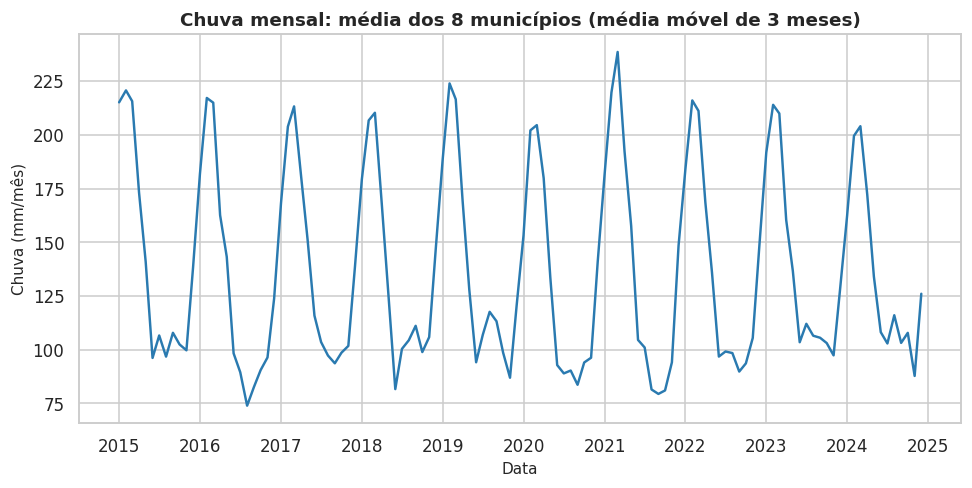

In [28]:
fig = fig_serie(df, "chuva_mm", "mean", "Chuva mensal: média dos 8 municípios", "Chuva (mm/mês)", janela=3, cor=COR_CHUVA)
salvar(fig, "01_linha_chuva")

**Interpretação:** a chuva tem um **ciclo anual muito regular**: picos de ~200 a 240 mm todo verão (dezembro a março) e vales de ~75 a 105 mm nos meses menos chuvosos. Não há tendência de aumento ou queda entre 2015 e 2024: a chuva média anual dos municípios ficou entre 1.560 e 1.713 mm.

### 9.2 Linha temporal — evolução dos deslizamentos

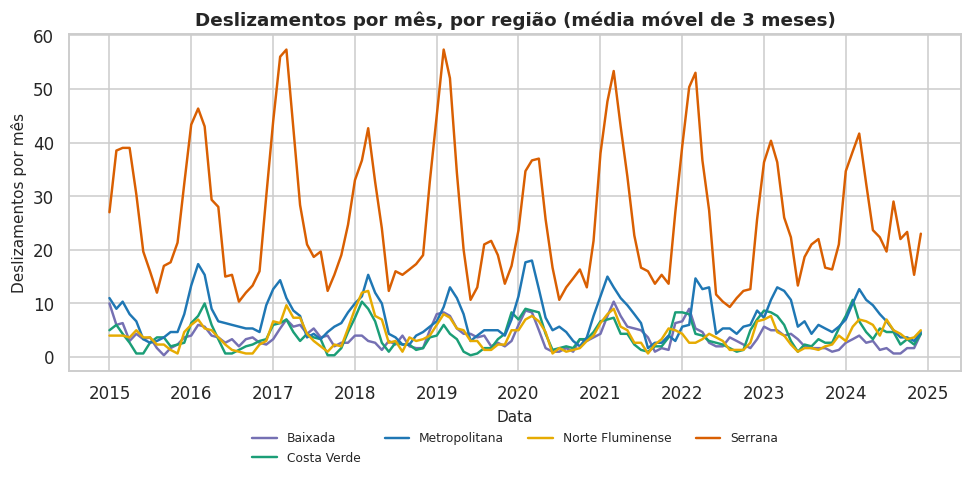

In [29]:
fig = fig_serie(df, "ocorrencias_deslizamento", "sum", "Deslizamentos por mês, por região", "Deslizamentos por mês", por="regiao_rj", janela=3)
salvar(fig, "02_linha_deslizamentos")

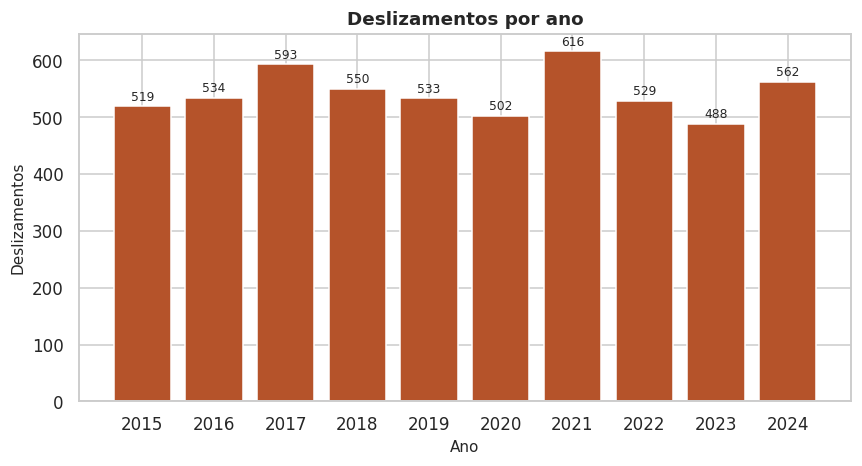

In [30]:
fig = fig_barras_ano(por_ano["deslizamentos"], "Deslizamentos por ano", "Deslizamentos", cor=COR_DESLIZ)
salvar(fig, "13_deslizamentos_ano")

**Interpretação:** os deslizamentos **repetem o ciclo da chuva**, e a região **Serrana** (laranja) tem picos de 40 a 60 ocorrências por mês (somando seus 3 municípios), muito acima das demais regiões: a Metropolitana (2 municípios) chega a ~18 e as outras ficam em torno de 10 a 12. O total anual oscila entre 488 (2023) e 616 (2021), **sem tendência** (correlação com o ano: r = -0,04; p = 0,91).

### 9.3 Barras por município — deslizamentos e chuva

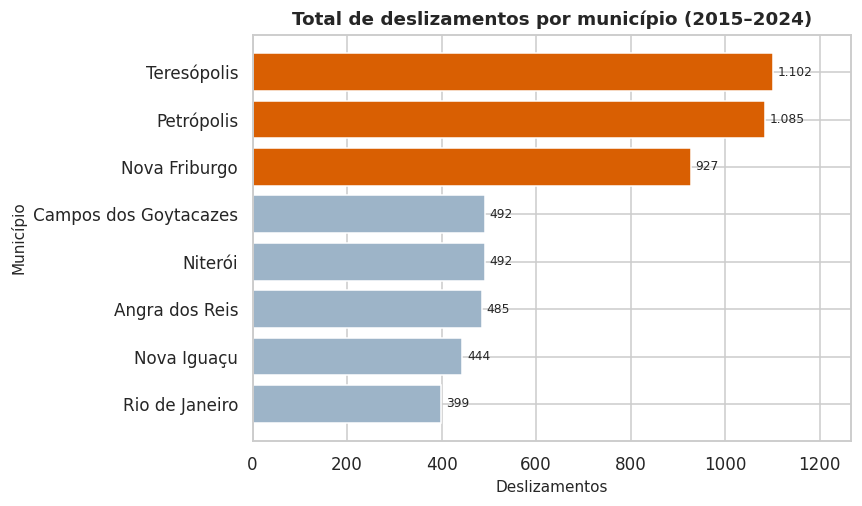

In [31]:
fig = fig_barras(df, "municipio", "ocorrencias_deslizamento", "sum", "Total de deslizamentos por município (2015–2024)", "Deslizamentos")
salvar(fig, "03_barras_deslizamentos_municipio")

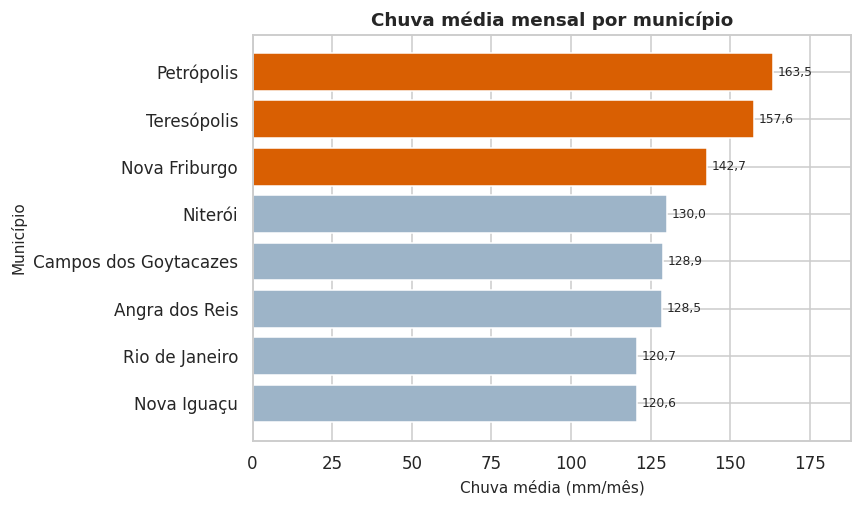

In [32]:
fig = fig_barras(df, "municipio", "chuva_mm", "mean", "Chuva média mensal por município", "Chuva média (mm/mês)", fmt="{:,.1f}")
salvar(fig, "04_barras_chuva_municipio")

**Interpretação:** **Petrópolis** (163,5 mm/mês), **Teresópolis** (157,6 mm) e **Nova Friburgo** (142,7 mm) são os que **mais recebem chuva**, todos serranos; **Nova Iguaçu** é o que menos recebe (120,6 mm). Nos deslizamentos a diferença é muito maior: **Teresópolis** (1.102), **Petrópolis** (1.085) e **Nova Friburgo** (927) têm de 1,9 a 2,2 vezes o total do quarto colocado (Niterói, 492). A Serrana recebe cerca de **23% mais chuva** que as demais regiões, mas tem cerca de **124% mais deslizamentos por município**: a chuva **não explica sozinha** a diferença, o que indica vulnerabilidade própria da Serrana.

### 9.4 Dispersão — chuva × deslizamentos

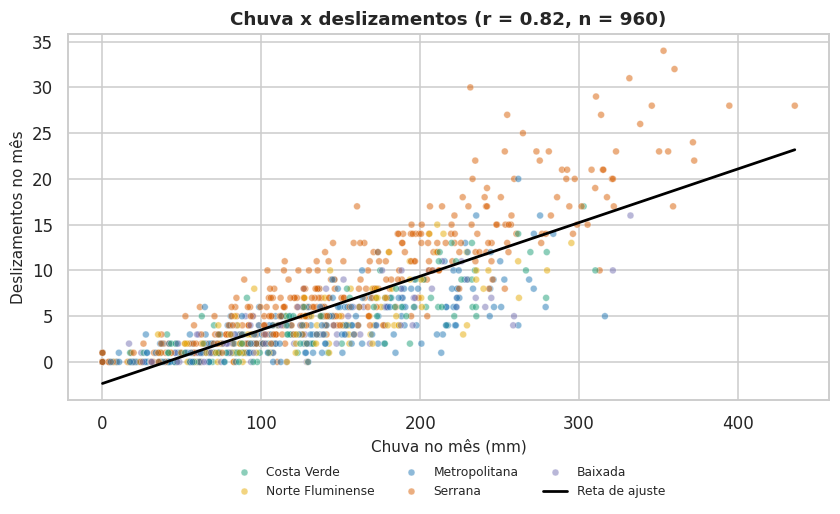

In [33]:
fig = fig_dispersao(df, "chuva_mm", "ocorrencias_deslizamento", "Chuva x deslizamentos", "Chuva no mês (mm)", "Deslizamentos no mês")
salvar(fig, "05_dispersao_chuva_deslizamentos")

**Interpretação:** a nuvem de pontos sobe com a chuva (r = 0,82), e os pontos laranja (**Serrana**) ficam sistematicamente **acima** da reta: para a mesma chuva, há mais deslizamentos. A dispersão cresce com a chuva (os mesmos 300 mm podem gerar de 10 a 30 ocorrências), o que mostra que **outros fatores** (solo, relevo, ocupação) também pesam.

### 9.5 Heatmaps — sazonalidade

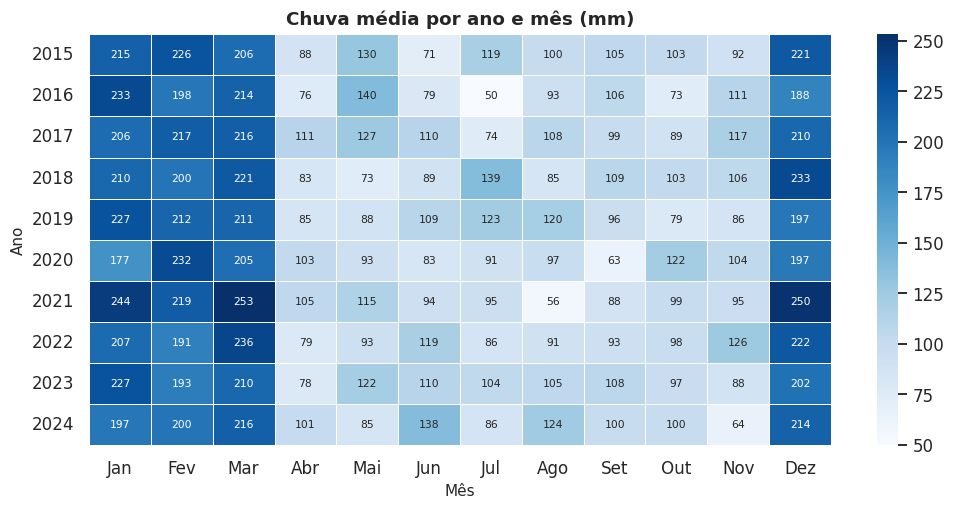

In [34]:
fig = fig_heatmap(df, "chuva_mm", "mean", "Chuva média por ano e mês (mm)", cmap="Blues")
salvar(fig, "06_heatmap_chuva_ano_mes")

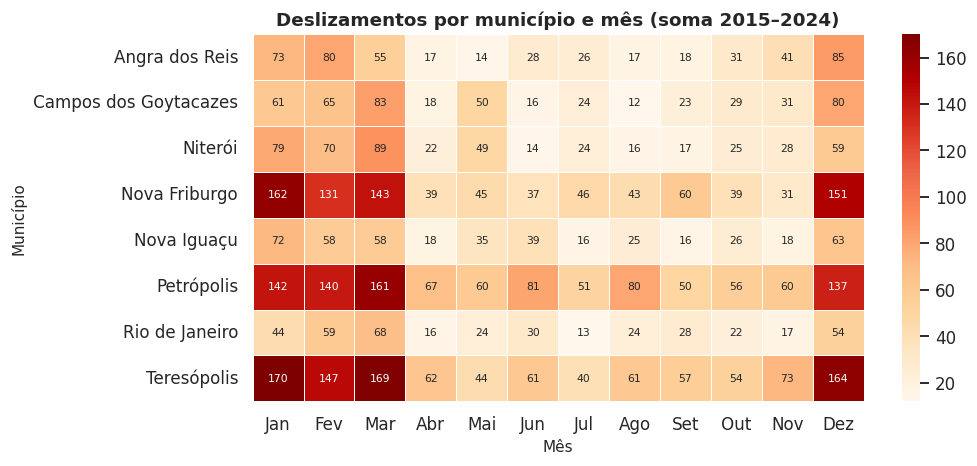

In [35]:
fig = fig_heatmap(df, "ocorrencias_deslizamento", "sum", "Deslizamentos por município e mês (soma 2015–2024)", cmap="OrRd", index="municipio")
salvar(fig, "07_heatmap_deslizamentos_municipio_mes")

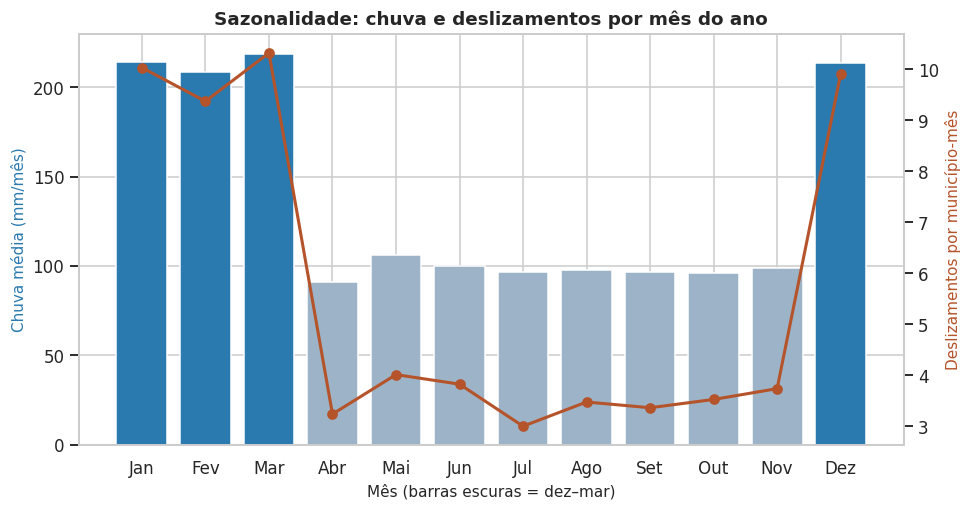

In [36]:
fig = fig_sazonal_dupla(df)
salvar(fig, "08_sazonalidade_chuva_deslizamentos")

**Interpretação:** o heatmap de chuva mostra uma **faixa escura fixa de dezembro a março** em todos os anos. O de deslizamentos confirma que **Petrópolis, Teresópolis e Nova Friburgo** somam entre 131 e 170 ocorrências (nos 10 anos) em cada mês do verão, contra no máximo 89 nos demais municípios. O mês **mais crítico é Mar** (10,3 deslizamentos por município) e o mais calmo, **Jul** (3,0). O gráfico duplo mostra que as barras (chuva) e a linha (deslizamentos) **sobem e descem juntas**.

### 9.6 Nível de risco

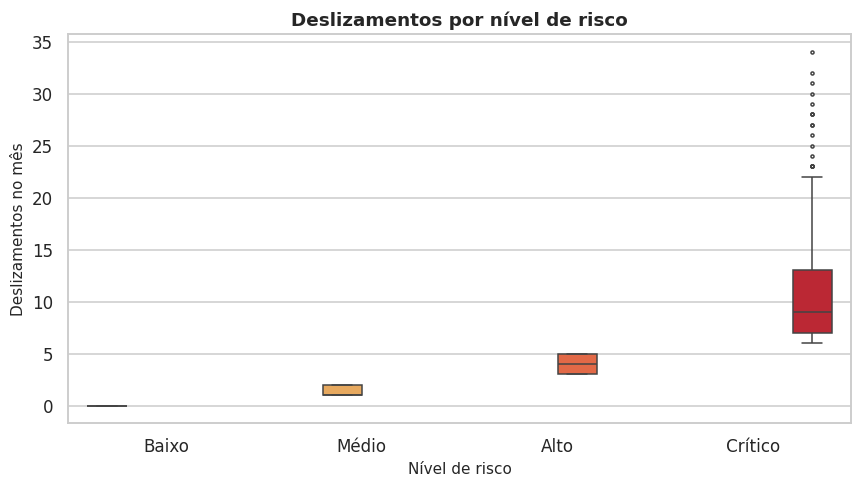

In [37]:
fig = fig_boxplot_risco(df)
salvar(fig, "09_boxplot_risco")

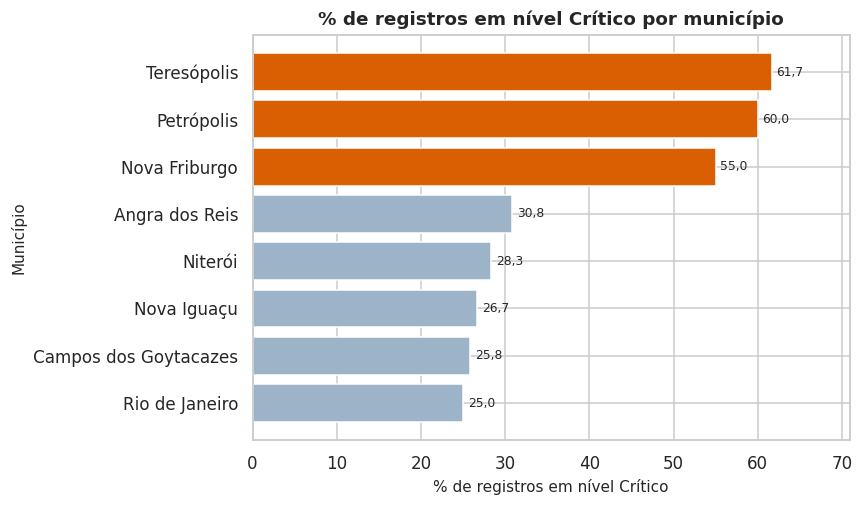

In [38]:
fig = fig_barras(df, "municipio", "critico_pct", "mean", "% de registros em nível Crítico por município", "% de registros em nível Crítico", fmt="{:,.1f}")
salvar(fig, "10_pct_critico_municipio")

**Interpretação:** o nível de risco **acompanha os deslizamentos**: a mediana vai de 0 (Baixo) a cerca de 9 (Crítico). Os três serranos têm **55% a 62%** dos registros em nível Crítico, contra **25% a 31%** nos demais. Cerca de 39% de todos os registros estão no nível Crítico.

### 9.7 Ranking e municípios fora do padrão

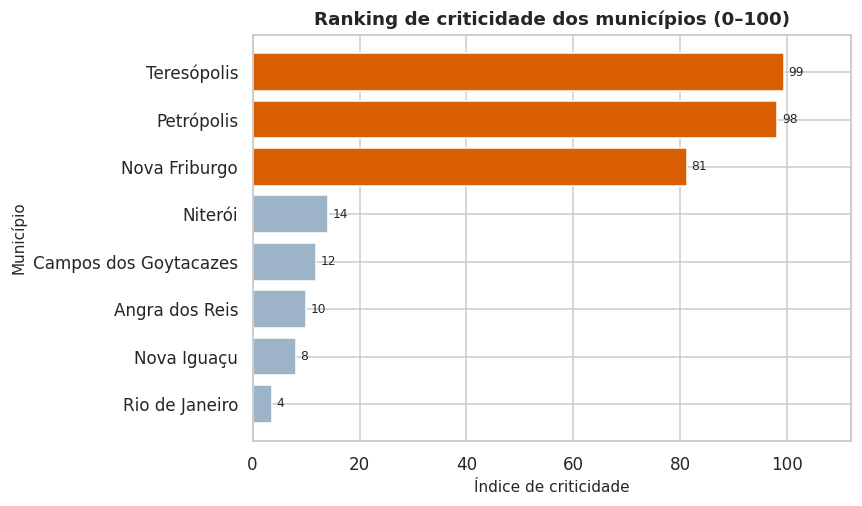

In [39]:
fig = fig_ranking(df)
salvar(fig, "11_ranking_criticidade")

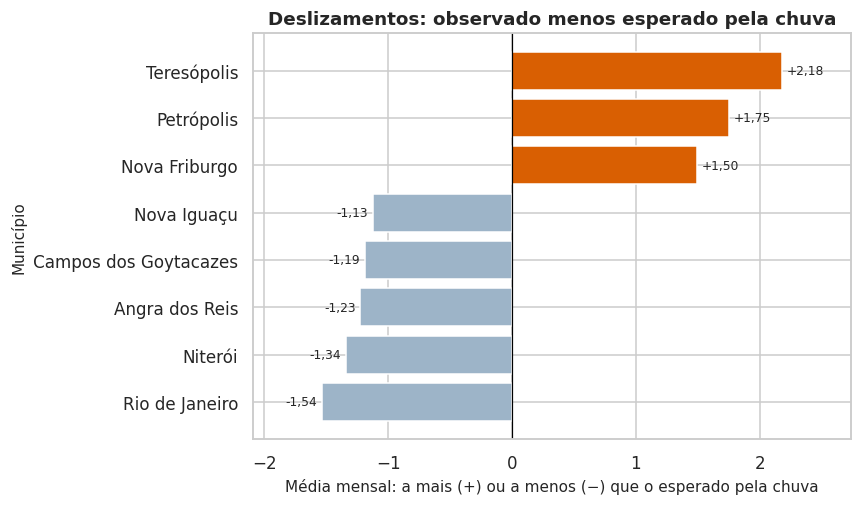

In [40]:
fig = fig_residuos(df)
salvar(fig, "12_municipios_fora_do_padrao")

**Interpretação:** o ranking separa dois grupos: **Serrana (índice 81 a 99)** e o resto (4 a 14). O gráfico de resíduos mostra que só os serranos ficam **acima** do esperado pela chuva.

### 9.8 Correlação defasada e matriz de correlação

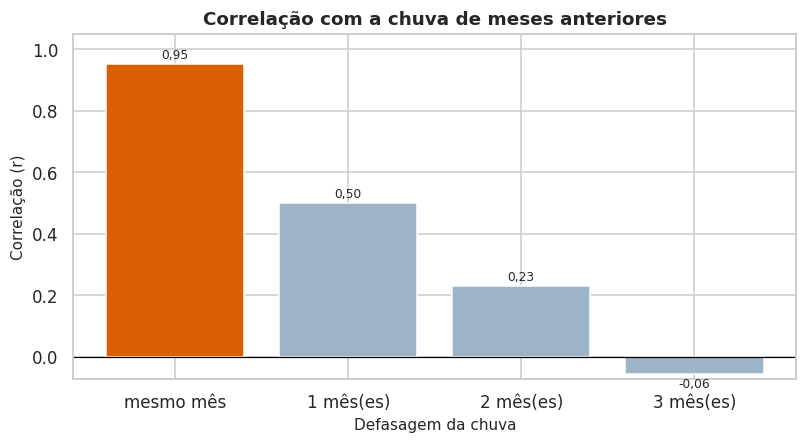

In [41]:
fig = fig_defasagem(df)
salvar(fig, "14_correlacao_defasada")

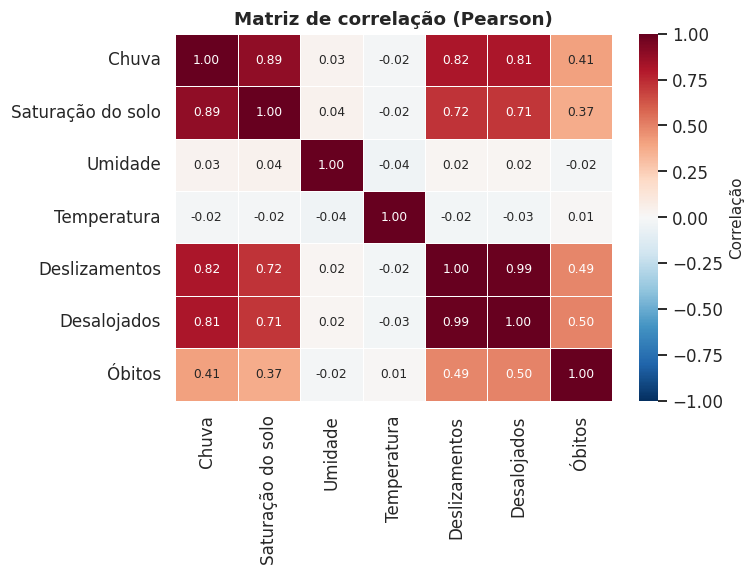

In [42]:
fig = fig_correlacao(df)
salvar(fig, "15_matriz_correlacao")

**Interpretação:** o efeito da chuva é **imediato** (r = 0,95 no mesmo mês, 0,50 com 1 mês de defasagem). Na matriz, a chuva se relaciona com o solo saturado (0,89), com os deslizamentos (0,82) e, mais fracamente, com os óbitos (0,41); umidade e temperatura ficam em torno de zero.

### 9.9 Tabela dinâmica — exploração detalhada

In [43]:
# Deslizamentos (soma) por município (linhas) e nível de risco (colunas)
pd.pivot_table(df, index="municipio", columns="nivel_risco", values="ocorrencias_deslizamento", aggfunc="sum", observed=True, margins=True, margins_name="Total")

nivel_risco,Baixo,Médio,Alto,Crítico,Total
municipio,,,,,
Angra dos Reis,0,54,107,324,485
Campos dos Goytacazes,0,52,150,290,492
Niterói,0,51,129,312,492
Nova Friburgo,0,23,102,802,927
Nova Iguaçu,0,47,140,257,444
Petrópolis,0,23,120,942,1085
Rio de Janeiro,0,57,122,220,399
Teresópolis,0,24,99,979,1102
Total,0,331,969,4126,5426


In [44]:
# Chuva média (mm) por região (linhas) e estação do ano (colunas)
pd.pivot_table(df, index="regiao_rj", columns="estacao", values="chuva_mm", aggfunc="mean", observed=True).round(1)

estacao,Chuvosa (dez–mar),Menos chuvosa (abr–nov)
regiao_rj,,
Baixada,186.10,87.90
Costa Verde,203.80,90.80
Metropolitana,197.50,89.30
Norte Fluminense,190.90,98.00
Serrana,244.80,109.50


## 10. Interpretação dos resultados

**O que os dados indicam?**

1. **A chuva é o principal gatilho** dos deslizamentos: r = 0,82, **+5,9 deslizamentos a cada 100 mm**, com efeito imediato e crescente (dose-resposta).
2. **Forte sazonalidade:** dezembro a março concentram **58%** dos deslizamentos e **66%** dos óbitos em 33% dos meses.
3. **A Serrana é a região mais vulnerável:** Teresópolis, Petrópolis e Nova Friburgo têm **57%** dos deslizamentos, 55% a 62% dos registros em nível Crítico e mais ocorrências do que a chuva explicaria (resíduos positivos, p < 0,001).
4. **Solo saturado + chuva intensa** formam uma regra de alerta: 20% dos meses, 47% dos deslizamentos.
5. **Sem tendência temporal:** nem a chuva nem os deslizamentos aumentaram entre 2015 e 2024.

**Evidências e comparações**
- Testes ANOVA (municípios e regiões), Mann-Whitney (estação chuvosa × resto) e correlações de Pearson e Spearman, todos com p < 0,001 nos pontos principais.
- Comparação Serrana × demais regiões (inclinação 7,1 × 4,0 deslizamentos por 100 mm).

**Limitações dos dados**

- **Dados simulados** e apenas **8 municípios**; uma observação por município e mês (sem dados diários, que permitiriam estudar chuva acumulada em poucos dias).
- **`populacao` inconsistente** (muda a cada mês, de ~120 mil a ~6,5 milhões): não foi possível calcular taxas por habitante.
- **`desalojados` é redundante** com os deslizamentos (r = 0,99).
- **`nivel_risco` não é função exata** da chuva (faixas sobrepostas).
- A **relação é de associação**, não prova causalidade; falta informação de relevo, ocupação e obras de contenção.
- O resíduo por município usa uma **reta global puxada pela Serrana**, o que faz os demais parecerem “abaixo do esperado”.

## 11. Conclusão

**Principais descobertas**
- Chuva média de **136,6 mm/mês**; **5.426 deslizamentos**, **54.371 desalojados** e **268 óbitos** em 2015–2024.
- Município mais crítico: **Teresópolis** (1.102 deslizamentos), seguido de **Petrópolis** e **Nova Friburgo**.
- Correlação chuva × deslizamentos: **r = 0,82** (muito forte).
- Meses mais críticos: **dezembro a março** (pico em Mar).

**Resposta à pergunta inicial.** A chuva intensa **aumenta fortemente** os deslizamentos, e o efeito é imediato e crescente. Os deslizamentos se concentram em **dois eixos**: o **tempo** (verão) e o **lugar** (região Serrana: Teresópolis, Petrópolis e Nova Friburgo, que têm mais deslizamentos do que a chuva sozinha explicaria).

**Decisões possíveis**
1. **Priorizar a região Serrana** em obras de contenção, mapeamento de áreas de risco e defesa civil.
2. **Operar em modo de alerta de dezembro a março**, sem abandonar o monitoramento nos demais meses (42% dos deslizamentos).
3. **Alerta por chuva e solo:** acionar quando a chuva superar 200 mm e o solo estiver saturado (≥ 0,8).

**Sugestões futuras:** dados diários e chuva acumulada em 24/72 h; relevo, declividade e população em áreas de risco; mais municípios; modelo preditivo (por exemplo, regressão de Poisson); mapa de calor por bairro; comparação com a chuva observada pela API Open-Meteo (já disponível no dashboard).

## 12. Reflexão final (data storytelling)

**Se eu apresentasse este projeto a um gestor:**

> *“Os deslizamentos seguem a chuva e o lugar: quase 6 em cada 10 acontecem em apenas três cidades serranas, e mais da metade ocorre de dezembro a março. Se temos recursos limitados, é nesses três municípios, nesses quatro meses e nos dias de chuva forte com solo encharcado que eles devem ser aplicados.”*

**Ação recomendada:** (1) concentrar obras e defesa civil em Teresópolis, Petrópolis e Nova Friburgo; (2) alerta e mobilização preventiva de dezembro a março; (3) gatilho de alerta por chuva (≥ 200 mm) com solo saturado.